

# Classification Models with Keras




## Import Keras and Packages


### Import the libraries. 
There might be some warning messages related to floating point round off errors and lack of GPU and other compiler related options. You can ignore these warnings and proceed.


In [24]:
import keras

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

Since we are dealing we images, let's also import the Matplotlib scripting layer in order to view the images.


In [25]:
import matplotlib.pyplot as plt

In [26]:
# import the data
from keras.datasets import mnist

# read the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

Let's confirm the number of images in each set. According to the dataset's documentation, we should have 60000 images in X_train and 10000 images in the X_test.


In [27]:
X_train.shape

(60000, 28, 28)

The first number in the output tuple is the number of images, and the other two numbers are the size of the images in datset. So, each image is 28 pixels by 28 pixels.


Let's visualize the first image in the training set using Matplotlib's scripting layer.


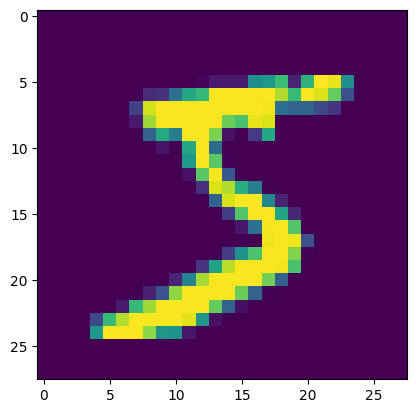

In [ ]:
plt.imshow(X_train[0])

With conventional neural networks, we cannot feed in the image as input as is. So we need to flatten the images into one-dimensional vectors, each of size 1 x (28 x 28) = 1 x 784.


In [29]:
# flatten images into one-dimensional vector

num_pixels = X_train.shape[1] * X_train.shape[2] # find size of one-dimensional vector

X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32') # flatten training images
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32') # flatten test images

Since pixel values can range from 0 to 255, let's normalize the vectors to be between 0 and 1.


In [30]:
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255

Finally, before we start building our model, remember that for classification we need to divide our target variable into categories. We use the to_categorical function from the Keras Utilities package.


In [41]:
# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1]
print(num_classes)

10


## Build a Neural Network


In [ ]:
# define classification model
def classification_model():
    # create model
    
    model = Sequential()
    model.add(Input(shape=(num_pixels,)))
    
    model.add(Dense(num_pixels, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## Train and Test the Network


In [33]:
# build the model
model = classification_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)

Epoch 1/10
1875/1875 - 25s - 13ms/step - accuracy: 0.9430 - loss: 0.1860 - val_accuracy: 0.9671 - val_loss: 0.1032
Epoch 2/10
1875/1875 - 40s - 22ms/step - accuracy: 0.9754 - loss: 0.0775 - val_accuracy: 0.9757 - val_loss: 0.0787
Epoch 3/10
1875/1875 - 25s - 13ms/step - accuracy: 0.9837 - loss: 0.0526 - val_accuracy: 0.9690 - val_loss: 0.1011
Epoch 4/10
1875/1875 - 26s - 14ms/step - accuracy: 0.9869 - loss: 0.0408 - val_accuracy: 0.9792 - val_loss: 0.0726
Epoch 5/10
1875/1875 - 39s - 21ms/step - accuracy: 0.9892 - loss: 0.0325 - val_accuracy: 0.9805 - val_loss: 0.0763
Epoch 6/10
1875/1875 - 23s - 12ms/step - accuracy: 0.9916 - loss: 0.0251 - val_accuracy: 0.9805 - val_loss: 0.0754
Epoch 7/10
1875/1875 - 25s - 13ms/step - accuracy: 0.9928 - loss: 0.0226 - val_accuracy: 0.9757 - val_loss: 0.1019
Epoch 8/10
1875/1875 - 25s - 13ms/step - accuracy: 0.9933 - loss: 0.0200 - val_accuracy: 0.9809 - val_loss: 0.0866
Epoch 9/10
1875/1875 - 23s - 12ms/step - accuracy: 0.9947 - loss: 0.0176 - val_a

Let's print the accuracy and the corresponding error.


In [34]:
print('Accuracy: {}% \n Error: {}'.format(scores[1], 1 - scores[1]))        

Accuracy: 0.9772999882698059% 
 Error: 0.022700011730194092


Sometimes, you cannot afford to retrain your model everytime you want to use it, especially if you are limited on computational resources and training your model can take a long time. Therefore, with the Keras library, you can save your model after training. To do that, we use the save method.


In [35]:
model.save('classification_model.keras')

Since our model contains multidimensional arrays of data, then models are usually saved as .keras files.


When you are ready to use your model again, you use the load_model function from <strong>keras.saving</strong>.


In [36]:
pretrained_model = keras.saving.load_model('classification_model.keras')